kernel: 3.9.6 (.venv)

## Imports

In [1715]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats
from scipy.stats import norm
import requests
import os
import plotly.graph_objects as go
import dataframe_image as dfi
import time
from bs4 import BeautifulSoup # library to parse HTML documents
from collections import Counter
import re
import pyfolio as pf
import itertools
from itertools import chain
import matplotlib.ticker as mtick
# import networkx as nx
from upsetplot import from_contents
from upsetplot import plot
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib.lines as mlines
from matplotlib.dates import DateFormatter, DayLocator
import imgkit
%matplotlib inline

import cvxpy as cp
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

import openai

import cplex

import cvxpy as cp
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

# from __future__ import print_function


In [1716]:
model = "gpt-4"
# model = "gpt-3.5-turbo-0613"
# model = 'gpt-4-1106-preview'

In [1717]:
avg_weights = True
# avg_weights = False

Install CPLEX solver. To setup CPLEX solver for Python:
* Use the script `setup.py` located in the directory `yourCPLEXhome/python`
* Execute the following command from the command line `python yourCPLEXhome/python/setup.py install` or `python yourCPLEXhome/python/setup.py install --home yourPythonPackageshome`
* Set the environment variable `PYTHONPATH` to `yourCPLEXhome/python/VERSION/PLATFORM`

## Identify sector parameters

In [1718]:
# sector_name = 'energy'
# sector_name_full = 'Energy'
# sector_ticker = '^GSPE'
# full_ticker = 'SP500-10'

In [1719]:
# sector_name = 'materials'
# sector_name_full = 'Materials'
# sector_ticker = '^SP500-15'
# full_ticker = 'SP500-15'

In [1720]:
# sector_name = 'industrials'
# sector_name_full = 'Industrials'
# sector_ticker = '^SP500-20'
# full_ticker = 'SP500-20'

In [1721]:
# sector_name = 'consumer_discretionary'
# sector_name_full = 'Consumer Discretionary'
# sector_ticker = '^SP500-25'
# full_ticker = 'SP500-25'

In [1722]:
# sector_name = 'consumer_staples'
# sector_name_full = 'Consumer Staples'
# sector_ticker = '^SP500-30'
# full_ticker = 'SP500-30'

In [1723]:
# sector_name = 'health_care'
# sector_name_full = 'Health Care'
# sector_ticker = '^SP500-35'
# full_ticker = 'SP500-35'

In [1724]:
# sector_name = 'financials'
# sector_name_full = 'Financials'
# sector_ticker = '^SP500-40'
# full_ticker = 'SP500-40'

In [1725]:
# sector_name = 'information_technology'
# sector_name_full = 'Information Technology'
# sector_ticker = '^SP500-45'
# full_ticker = 'SP500-45'

In [1726]:
# sector_name = 'communication_services'
# sector_name_full = 'Communication Services'
# sector_ticker = '^SP500-50'
# full_ticker = 'SP500-50'

In [1727]:
# sector_name = 'utilities'
# sector_name_full = 'Utilities'
# sector_ticker = '^SP500-55'
# full_ticker = 'SP500-55'

In [1728]:
sector_name = 'real_estate'
sector_name_full = 'Real Estate'
sector_ticker = '^SP500-60'
full_ticker = 'SP500-60'

## Process data

In [1729]:
df = pd.read_csv(f'sector_dfs/{sector_name}.csv')

companies = df.columns[2:]

## In-sample end date (using 5 years of weekly data prior to end date)
insample_enddate = datetime(2023, 3, 31)

# Out-of-sample period (1 Apr 2023 to 1 Dec 2023)(using daily data)
outsample_startdate = datetime(2023, 4, 1)
outsample_enddate  = datetime(2023, 12,  1)

insample_startdate = insample_enddate - timedelta(weeks=5*52) # five years prior to April 2023

In [1730]:
df = pd.read_csv(f'sector_dfs/{sector_name}.csv')

sp500_df = pd.read_csv('SP500.csv')
companies = sp500_df[sp500_df['GICS Sector'] == sector_name_full]['Symbol']
companies

14      ARE
29      AMT
52      AVB
72      BXP
83      CPT
93     CBRE
132    CSGP
135     CCI
148     DLR
176    EQIX
177     EQR
178     ESS
187     EXR
193     FRT
227    PEAK
237     HST
260    INVH
262     IRM
277     KIM
319     MAA
382     PLD
386     PSA
395       O
396     REG
410    SBAC
416     SPG
456     UDR
465     VTR
473    VICI
486    WELL
490      WY
Name: Symbol, dtype: object

## Load data

In [1731]:
index_tickers = ["^GSPC", "^IXIC", sector_ticker]

index_data_outs = pd.DataFrame()

# Download historical data for each index for out-of-sample period 1
for ticker in index_tickers:
    index_df = yf.download(ticker, start=outsample_startdate, end=outsample_enddate, interval='1d')
    index_df['Index_Return'] = index_df['Adj Close'].pct_change()
    index_df.dropna(subset=['Index_Return'], inplace=True)
    index_data_outs[ticker] = index_df['Index_Return']

# Set the index of out-of-sample data to datetime format
index_data_outs.index = pd.to_datetime(index_data_outs.index)

# Create empty lists to store the tickers with continuous data in each out-of-sample period
valid_index_tickers_outs = []

for ticker in index_tickers:
    # Check if the ticker has continuous data in out-of-sample period 1
    if ticker in index_data_outs.columns and index_data_outs[ticker].notna().all():
        valid_index_tickers_outs.append(ticker)


index_tickers = valid_index_tickers_outs

print("Valid Index Tickers in Out-of-Sample Period")
print(valid_index_tickers_outs)


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
Valid Index Tickers in Out-of-Sample Period
['^GSPC', '^IXIC', '^SP500-60']


In [1732]:
index_tickers = ["^GSPC", "^IXIC", sector_ticker]

index_data_ins = pd.DataFrame()

# Download historical data for each index for out-of-sample period 1
for ticker in index_tickers:
    index_df = yf.download(ticker, start=insample_startdate, end=insample_enddate, interval='1wk')
    index_df['Index_Return'] = index_df['Adj Close'].pct_change()
    index_df.dropna(subset=['Index_Return'], inplace=True)
    index_data_ins[ticker] = index_df['Index_Return']

# Set the index of out-of-sample data to datetime format
index_data_ins.index = pd.to_datetime(index_data_ins.index)

# Create empty lists to store the tickers with continuous data in each out-of-sample period
valid_index_tickers_ins = []

for ticker in index_tickers:
    # Check if the ticker has continuous data in out-of-sample period 1
    if ticker in index_data_ins.columns and index_data_ins[ticker].notna().all():
        valid_index_tickers_ins.append(ticker)


# index_tickers = valid_index_tickers_ins

print("Valid Index Tickers in In-Sample Period")
print(valid_index_tickers_ins)


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
Valid Index Tickers in In-Sample Period
['^GSPC', '^IXIC']


In [1733]:
## In-sample end date (using 5 years of weekly data prior to end date)
insample_enddate = datetime(2023, 3, 31)

## Out-of-sample period (1 Apr 2023 to 1 Dec 2023) (using daily data))
outsample_startdate = datetime(2023, 4, 1)
outsample_enddate   = datetime(2023, 12,  1)

insample_startdate = insample_enddate - timedelta(weeks=5*52) # five years prior to April 2023

In [1734]:
# in-sample
sp500_ins = yf.download(sector_ticker, start=insample_startdate, end=insample_enddate, interval='1wk')
sp500_ins['SP_Return'] = sp500_ins['Adj Close'].pct_change()

# Drop NA values in S&P 500 return data
sp500_ins.dropna(subset=['SP_Return'], inplace=True) # 1256 X 7 (removed first row with NaN in return)

# out-of-sample
sp500_outs = yf.download(sector_ticker, start=outsample_startdate, end=outsample_enddate)
sp500_outs['SP_Return'] = sp500_outs['Adj Close'].pct_change()

# Drop NA values in S&P 500 return data
sp500_outs.dropna(subset=['SP_Return'], inplace=True) # removed first row with NaN in return

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


In [1735]:
insample_data_filename = f'4_returns_insample/SP500_{sector_name}_returns_till_Apr2023.csv'
outsample_data_filename = f'4_returns_outsample/SP500_{sector_name}_returns_since_Apr2023.csv'

In [1736]:
print("Reading data from file", insample_data_filename)
df_returns = pd.read_csv(insample_data_filename, index_col=0)

print("Reading data from file", outsample_data_filename)
df_returnsOUT = pd.read_csv(outsample_data_filename, index_col=0)

Reading data from file 4_returns_insample/SP500_real_estate_returns_till_Apr2023.csv
Reading data from file 4_returns_outsample/SP500_real_estate_returns_since_Apr2023.csv


## Processing

In [1737]:
def process_sector_data(df_sector):
    stocks = list(df_sector['Stock'].str.replace(" ", "").values)
    eq_weights = [1/len(stocks)] * len(stocks)
    gpt_weights = list(df_sector['Weight'].values.astype(float))

    return stocks, eq_weights, gpt_weights

In [1738]:
csv_filename = f'4_avg_weights_assigned/responses15_auto_{sector_name}.csv'

if model == 'gpt-4' and not avg_weights:
    csv_filename = f'4_weights_assigned/responses15_auto_{sector_name}.csv'
elif model == 'gpt-3.5-turbo-0613' and not avg_weights:
    csv_filename = f'3_weights_assigned/responses15_auto_{sector_name}.csv'
elif model == 'gpt-4-1106-preview' and not avg_weights:
    csv_filename = f'4preview_weights_assigned/responses15_auto_{sector_name}.csv'

elif model == 'gpt-4' and avg_weights:
    csv_filename = f'4_avg_weights_assigned/responses15_auto_{sector_name}.csv'
elif model == 'gpt-3.5-turbo-0613' and avg_weights:
    csv_filename = f'3_avg_weights_assigned/responses15_auto_{sector_name}.csv'
elif model == 'gpt-4-1106-preview' and  avg_weights:
    csv_filename = f'4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'


In [1739]:
# df_sector_3 = pd.read_csv(f'3_weights_assigned/responses15_auto_{sector_name}.csv')

# stocks_3, eq_weights_3, gpt_weights_3 = process_sector_data(df_sector_3)

# globals()[f'3_stocks_{sector_name}'] = stocks_3

# # Assign variables dynamically
# globals()[f'3_df_{sector_name}'] = df_sector_3
# globals()[f'3_stocks_{sector_name}'] = stocks_3
# globals()[f'3_eq_weights_{sector_name}'] = eq_weights_3
# globals()[f'3_weights_gpt_{sector_name}'] = gpt_weights_3

In [1740]:
df_sector = pd.read_csv(csv_filename)

stocks, eq_weights, gpt_weights = process_sector_data(df_sector)

globals()[f'stocks_{sector_name}'] = stocks

# Assign variables dynamically
globals()[f'df_{sector_name}'] = df_sector
globals()[f'stocks_{sector_name}'] = stocks
globals()[f'eq_weights_{sector_name}'] = eq_weights
globals()[f'weights_gpt_{sector_name}'] = gpt_weights

In [1741]:
globals()[f'stock_returns_{sector_name}'] = df_returnsOUT[globals()[f'stocks_{sector_name}']]
# globals()[f'3_stock_returns_{sector_name}'] = df_returnsOUT[globals()[f'3_stocks_{sector_name}']]

In [1742]:
tickers_sp500out = np.array(df_returnsOUT.columns)

In [1743]:
def frontiers(returns_df, asset_list, num_portf, lb, ub, risk_free_rate, model_name):
    # Calculate the covariance matrix and expected returns and scaling them to ANNUAL
    # ts_freq = np.diff(returns_df.index).min()
    try:
        ts_freq = pd.infer_freq(returns_df.index)[0]

        scalef = 252
        if ts_freq=='W':
            scalef = 52
        elif ts_freq=='M':
            scalef = 12
    except TypeError:        
        scalef = 52
        
    Q = returns_df[asset_list].cov() * scalef  # 52 weeks in a year
    mu_pd = returns_df[asset_list].mean() * scalef
    mu = mu_pd.values
    
    ## Minimum variance portfolio
    w = cp.Variable(len(asset_list))
    prob1 = cp.Problem(cp.Minimize(cp.quad_form(w, Q)),
                      [sum(w) == 1,
                       w >= 0])
    prob1.solve(solver=cp.CPLEX, verbose=False, cplex_params={"qpmethod": 6})
    w_minVar = w.value
    # var_minVar = np.dot(w_minVar, np.dot(Q, w_minVar))
    ret_minVar = np.dot(mu, w_minVar)
    
    ## Max return portfolio
    w = cp.Variable(len(asset_list))
    prob2 = cp.Problem(cp.Maximize(mu.T@w),
                    [sum(w) == 1,
                     w >= 0])
    prob2.solve(solver=cp.CPLEX, verbose=False, cplex_params={"qpmethod": 6})
    w_maxRet = w.value
    # var_maxRet = np.dot(w_maxRet, np.dot(Q, w_maxRet))
    ret_maxRet = np.dot(mu, w_maxRet)
    
    ## Efficient Frontier
    targetRet = np.linspace(ret_minVar, ret_maxRet, num_portf)
    w = cp.Variable(len(asset_list))
    eps = cp.Parameter()
    eps.value = targetRet[0]
    prob3 = cp.Problem(cp.Minimize(cp.quad_form(w, Q)),
                    [mu.T@w >= eps,
                     sum(w) == 1,
                     w >= 0])
    # Compute efficient frontier
    w_front = []
    var_front = []
    ret_front = []
    sharpe_ratio_front = []
    
    for epsilon in targetRet:
        eps.value = epsilon
        prob3.solve(solver=cp.CPLEX, verbose=False, cplex_params={"qpmethod": 6})
        w_front.append(w.value)
        var_front.append(np.dot(w.value, np.dot(Q, w.value)))
        ret_front.append(np.dot(mu, w.value))
        sharpe_ratio = (np.dot(mu, w.value) - risk_free_rate) / np.sqrt(np.dot(w.value, np.dot(Q, w.value)))
        sharpe_ratio_front.append(sharpe_ratio)
    
    # Find the portfolio with the maximum Sharpe ratio
    max_sharpe_ratio_index = np.argmax(sharpe_ratio_front)
    # weights_max_sharpe = w_front[max_sharpe_ratio_index]
    ret_max_sharpe = ret_front[max_sharpe_ratio_index]
    var_max_sharpe = var_front[max_sharpe_ratio_index]
        
    ## Minimum variance portfolio with bounds
    w = cp.Variable(len(asset_list))
    prob5 = cp.Problem(cp.Minimize(cp.quad_form(w, Q)),
                    [cp.sum(w) == 1,
                     w >= lb,
                     w <= ub])
    prob5.solve(solver=cp.CPLEX, verbose=False, cplex_params={"qpmethod": 6})
    w_minVar_bounded = w.value
    # var_minVar_bounded = np.dot(w_minVar_bounded, np.dot(Q, w_minVar_bounded))
    with open(f'efficient_portfolios/{model_name}_{sector_name}_minvar_bounded.csv', 'w', encoding='utf-8') as f:
        f.write(','.join(asset_list))
        f.write('\n')
        f.write(','.join([str(x) for x in w_minVar_bounded]))

    ret_minVar_bounded = np.dot(mu, w_minVar_bounded)
    
    ## Max return portfolio with bounds
    w = cp.Variable(len(asset_list))
    prob6 = cp.Problem(cp.Maximize(mu.T@w),
                        [cp.sum(w) == 1,
                         w >= lb,
                         w <= ub])
    prob6.solve(solver=cp.CPLEX, verbose=False, cplex_params={"qpmethod": 6})
    w_maxRet_bounded = w.value
    # var_maxRet_bounded = np.dot(w_maxRet_bounded, np.dot(Q, w_maxRet_bounded))
    ret_maxRet_bounded = np.dot(mu, w_maxRet_bounded)

    with open(f'efficient_portfolios/{model_name}_{sector_name}_maxret_bounded.csv', 'w', encoding='utf-8') as f:
        f.write(','.join(asset_list))
        f.write('\n')
        f.write(','.join([str(x) for x in w_maxRet_bounded]))
    # ret_maxRet_bounded = np.dot(mu, w_maxRet_bounded)    

    ## Efficient Frontier with bounds
    targetRetB = np.linspace(ret_minVar_bounded, ret_maxRet_bounded, num_portf)
    w = cp.Variable(len(asset_list))
    eps = cp.Parameter()
    eps.value = targetRetB[0]
    prob7 = cp.Problem(cp.Minimize(cp.quad_form(w, Q)),
                        [mu.T @ w >= eps,
                         cp.sum(w) == 1,
                         w >= lb,
                         w <= ub])
    w_front_bounded = []
    var_front_bounded = []
    ret_front_bounded = []
    sharpe_ratio_front_bounded = []
    
    for epsilon in targetRetB:
        eps.value = epsilon
        prob7.solve(solver=cp.CPLEX, verbose=False, cplex_params={"qpmethod": 6})
        w_front_bounded.append(w.value)
        var_front_bounded.append(np.dot(w.value, np.dot(Q, w.value)))

        ret_front_bounded.append(np.dot(mu, w.value))
        
        sharpe_ratio = (np.dot(mu, w.value) - risk_free_rate) / np.sqrt(np.dot(w.value, np.dot(Q, w.value)))
        sharpe_ratio_front_bounded.append(sharpe_ratio)
        
    # Find the portfolio with the maximum Sharpe ratio
    max_sharpe_ratio_bounded_index = np.argmax(sharpe_ratio_front_bounded)
    weights_max_sharpe_bounded = w_front_bounded[max_sharpe_ratio_bounded_index]
    with open(f'efficient_portfolios/{model_name}_{sector_name}_maxsharpe_bounded.csv', 'w', encoding='utf-8') as f:
        f.write(','.join(asset_list))
        f.write('\n')
        f.write(','.join([str(x) for x in weights_max_sharpe_bounded]))
    ret_max_sharpe_bounded = ret_front_bounded[max_sharpe_ratio_bounded_index]
    var_max_sharpe_bounded = var_front_bounded[max_sharpe_ratio_bounded_index]

    return (ret_front, var_front, ret_max_sharpe, var_max_sharpe, \
            ret_front_bounded, var_front_bounded, ret_max_sharpe_bounded, \
                var_max_sharpe_bounded, w_minVar_bounded, w_maxRet_bounded, weights_max_sharpe_bounded)

In [1744]:
lbA = 0.03
ubA = 0.13

In [1745]:
df_returns = pd.read_csv(f'4_returns_insample/SP500_{sector_name}_returns_till_Apr2023.csv')
try:
    df_returns['Date'] = pd.to_datetime(df_returns['Date'], format='%Y-%m-%d %H:%M:%S')
except ValueError:
    df_returns['Date'] = pd.to_datetime(df_returns['Date'] + ' 00:00:00', format='%Y-%m-%d %H:%M:%S')

df_returns = df_returns.set_index('Date')
# df_returns

In [1746]:
ret_front15, var_front15, ret_max_sharpe15, var_max_sharpe15, ret_front_bounded15, \
    var_front_bounded15, ret_max_sharpe_bounded15, var_max_sharpe_bounded15, w_min_var_bounded15, \
    w_max_ret_bounded15, w_max_sharpe_bounded15 = frontiers(df_returns, globals()[f'stocks_{sector_name}'], 200, lbA, ubA, 0.01, 'gpt-4')

## Plot frontiers

In [1747]:
def plot_frontiers(returns_df, params_gpt4, sector, model):
    asset_list, weights_eq, weights_gpt, ret_front, var_front, ret_max_sharpe, \
        var_max_sharpe, ret_front_bounded, var_front_bounded, ret_max_sharpe_bounded, \
            var_max_sharpe_bounded = params_gpt4
    
    # Calculate the covariance matrix and expected returns and scaling them to ANNUAL
    try:
        ts_freq = pd.infer_freq(returns_df.index)[0]

        scalef = 252
        if ts_freq=='W':
            scalef = 52
        elif ts_freq=='M':
            scalef = 12
    except TypeError:        
        scalef = 52

    Q = returns_df[asset_list].cov() * scalef  # 52 weeks in a year
    mu_pd = returns_df[asset_list].mean() * scalef
    mu = mu_pd.values
     
    # Compute expected returns, variances, and standard deviations for GPT weighted portfolio
    ret_gpt = np.dot(mu, weights_gpt)
    var_gpt = np.dot(weights_gpt, np.dot(Q, weights_gpt))
    std_gpt = np.sqrt(var_gpt)

    # Compute expected returns, variances, and standard deviations for equally weighted portfolio
    ret_eq = np.dot(mu, weights_eq)
    var_eq = np.dot(weights_eq, np.dot(Q, weights_eq))
    std_eq = np.sqrt(var_eq)

    fig = plt.figure(figsize=(10, 5), dpi=100, facecolor='w', edgecolor='k')
    ax = plt.gca()
    plt.rcParams['figure.figsize'] = [10, 5]

    ax.scatter(x=np.sqrt(var_front[0]), y=ret_front[0], marker='D', s=50, color='DarkGreen', label='minimum variance portfolio')
    ax.scatter(x=np.sqrt(var_front[-1]), y=ret_front[-1], marker='s', s=50, color='DarkMagenta', label='maximum return portfolio')
    ax.scatter(x=np.sqrt(var_front_bounded[0]), y=ret_front_bounded[0], marker='D', s=50, color='pink', label='minimum variance portfolio bounded')
    ax.scatter(x=np.sqrt(var_front_bounded[-1]), y=ret_front_bounded[-1], marker='s', s=50, color='brown', label='maximum return portfolio bounded')

    ax.plot(np.sqrt(var_front), ret_front, 'k--', label='efficient frontier')

    # Plot efficient frontier for bounded case
    ax.plot(np.sqrt(var_front_bounded), ret_front_bounded, 'k-', label='efficient frontier bounded')

    # Plot volatility versus expected return for individual stocks
    ax.scatter(x=np.sqrt(np.diag(Q)), y=mu, color='Blue', label='individual stocks')

    ax.scatter(x=std_gpt, y=ret_gpt, marker='o', s=50, color='red', label='GPT weighted GPT portfolio')

    ax.scatter(x=std_eq, y=ret_eq, marker='o', s=50, color='yellow', label='Equally weighted GPT portfolio')

    ax.scatter(x=np.sqrt(var_max_sharpe), y=ret_max_sharpe, marker='o', s=50, color='green', label='Maximum Sharpe portfolio')

    ax.scatter(x=np.sqrt(var_max_sharpe_bounded), y=ret_max_sharpe_bounded, marker='o', s=50, color='cyan', label='Maximum Sharpe portfolio bounded')

    # Format and display the final plot
    ax.axis([0.9 * np.sqrt(var_front[0]), 1.2 * np.max(np.sqrt(np.diag(Q))), np.min(mu) - 0.1 * (np.max(mu) - np.min(mu)), 1.1 * ret_front[-1]])
    ax.set_xlabel('Volatility (Standard Deviation)')
    ax.set_ylabel('Expected Return')
    plt.title(f'Efficient frontier for {str(len(asset_list))} stocks selected by {model} for {sector}')
    ax.legend(loc="lower right", fontsize='small')  # Adjust font size here
    ax.grid()
    plt.show()

In [1748]:
params_gpt4 = [globals()[f'stocks_{sector_name}'], globals()[f'eq_weights_{sector_name}'], globals()[f'weights_gpt_{sector_name}'], \
               ret_front15, var_front15, ret_max_sharpe15, var_max_sharpe15, ret_front_bounded15, var_front_bounded15, ret_max_sharpe_bounded15,\
                  var_max_sharpe_bounded15]


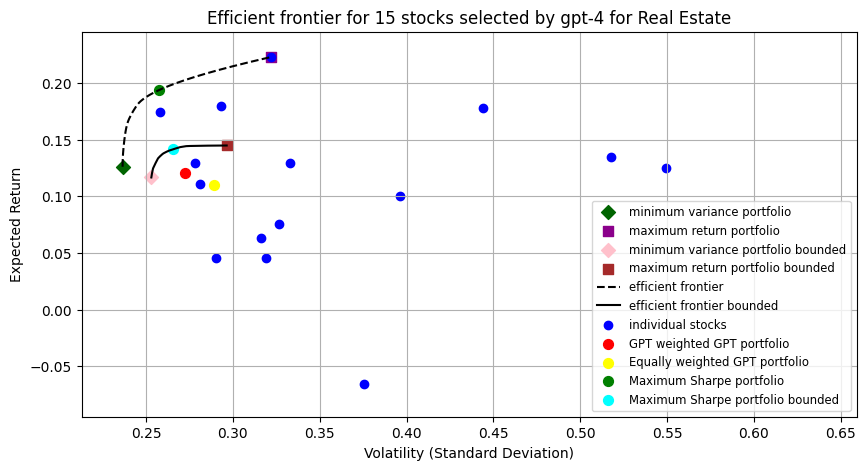

In [1749]:
plot_frontiers(df_returns, params_gpt4, sector_name_full, model)

## Plot portfolios performance

In [1750]:
# Weights of all portfolios
weights = {
    f"GPT4_weighted_{sector_name}": globals()[f'weights_gpt_{sector_name}'],
    f"GPT4_equal_{sector_name}": globals()[f'eq_weights_{sector_name}'],
    "GPT4 Min Var": w_min_var_bounded15,
    "GPT4 Max Ret": w_max_ret_bounded15,
    "GPT4 Max Sharpe": w_max_sharpe_bounded15
}

In [1751]:
temp_stock_return = globals()[f'stock_returns_{sector_name}']
cumulative_returns_gpt = pd.DataFrame(index=temp_stock_return.index)

In [1752]:
i = 0
for name, weight in weights.items():
    temp_stock_return = globals()[f'stock_returns_{sector_name}']
    portfolio_return = (temp_stock_return * weight).sum(axis=1)
    cumulative_returns_gpt[name] = (1 + portfolio_return).cumprod()
    i+=1

In [1753]:
cumulative_returns_gpt

,GPT4_weighted_real_estate,GPT4_equal_real_estate,GPT4 Min Var,GPT4 Max Ret,GPT4 Max Sharpe
Date,,,,,
2023-04-04,0.999066,0.997194,1.000495,0.996401,0.999984
2023-04-05,0.993555,0.992158,0.995005,0.990894,0.995797
2023-04-06,1.001337,0.999855,1.003398,0.999761,1.004225
2023-04-10,1.006900,1.006106,1.008084,1.007665,1.009189
2023-04-11,1.013058,1.013350,1.015039,1.013655,1.015220
...,...,...,...,...,...
2023-11-24,1.047609,1.048571,1.042551,1.039866,1.015180
2023-11-27,1.052506,1.051220,1.049586,1.042969,1.021187
2023-11-28,1.059069,1.057032,1.057252,1.045222,1.027437


In [1754]:
index_names = {
    sector_ticker: f'{full_ticker} {sector_name}'
}

cumulative_returns_gpt[index_names[sector_ticker]] = (1 + index_data_outs[ticker]).cumprod()

cumulative_returns_gpt.index = pd.to_datetime(cumulative_returns_gpt.index)
outsample_data = cumulative_returns_gpt.loc[outsample_startdate:outsample_enddate]

fig = go.Figure()


for column in outsample_data.columns:
    if column == f'{full_ticker} {sector_name}':
        fig.add_trace(go.Scatter(x=outsample_data.index,
                                 y=outsample_data[column],
                                 mode='lines',
                                 name=column,
                                 line=dict(width=3, color='red')))
    else:
        fig.add_trace(go.Scatter(x=outsample_data.index,
                                 y=outsample_data[column],
                                 mode='lines',
                                 name=column))


num_asset = len(df_sector)
fig.update_layout(
    title=f'Cumulative Returns of {num_asset} Asset Portfolios (GPT, equal weight) and {full_ticker} ({sector_name_full}) from Apr 23 to Dec 23',
    xaxis_title='Date',
    yaxis_title='Cumulative Returns',
    hovermode="x unified"
)

fig.show()

## Comparing GPT4, GPT3.5, GPT4 preview, Bard, Claude

In [1755]:
csv_filename = f'bard_avg_weights_assigned/responses15_auto_{sector_name}.csv'

df_sector_bard = pd.read_csv(csv_filename)

stocks_bard, eq_weights_bard, weights_bard = process_sector_data(df_sector_bard)

# Assign variables dynamically
globals()[f'bard_df_{sector_name}'] = df_sector_bard
globals()[f'bard_stocks_{sector_name}'] = stocks_bard
globals()[f'bard_eq_weights_{sector_name}'] = eq_weights_bard
globals()[f'bard_weights_{sector_name}'] = weights_bard

In [1756]:
csv_filename = f'claude_avg_weights_assigned/responses15_auto_{sector_name}.csv'

df_sector_claude = pd.read_csv(csv_filename)

stocks_claude, eq_weights_claude, weights_bard_claude = process_sector_data(df_sector_claude)

# Assign variables dynamically
globals()[f'claude_df_{sector_name}'] = df_sector_claude
globals()[f'claude_stocks_{sector_name}'] = stocks_claude
globals()[f'claude_eq_weights_{sector_name}'] = eq_weights_claude
globals()[f'claude_weights_{sector_name}'] = weights_bard_claude

In [1757]:
csv_filename = f'3_avg_weights_assigned/responses15_auto_{sector_name}.csv'

df_sector_gpt3 = pd.read_csv(csv_filename)

stocks_gpt3, eq_weights_gpt3, weights_gpt3 = process_sector_data(df_sector_gpt3)

# Assign variables dynamically
globals()[f'gpt3_df_{sector_name}'] = df_sector_gpt3
globals()[f'gpt3_stocks_{sector_name}'] = stocks_gpt3
globals()[f'gpt3_eq_weights_{sector_name}'] = eq_weights_gpt3
globals()[f'gpt3_weights_{sector_name}'] = weights_gpt3

In [1758]:
csv_filename = f'4preview_avg_weights_assigned/responses15_auto_{sector_name}.csv'

df_sector_gpt4preview = pd.read_csv(csv_filename)

stocks_gpt4preview, eq_weights_gpt4preview, weights_gpt4preview = process_sector_data(df_sector_gpt4preview)

# Assign variables dynamically
globals()[f'gpt4preview_df_{sector_name}'] = df_sector_gpt4preview
globals()[f'gpt4preview_stocks_{sector_name}'] = stocks_gpt4preview
globals()[f'gpt4preview_eq_weights_{sector_name}'] = eq_weights_gpt4preview
globals()[f'gpt4preview_weights_{sector_name}'] = weights_gpt4preview

In [1759]:
ret_front15_3, var_front15_3, ret_max_sharpe15_3, var_max_sharpe15_3, ret_front_bounded15_3, \
    var_front_bounded15_3, ret_max_sharpe_bounded15_3, var_max_sharpe_bounded15_3, w_min_var_bounded15_3, \
    w_max_ret_bounded15_3, w_max_sharpe_bounded15_3 = frontiers(df_returns, globals()[f'gpt3_stocks_{sector_name}'], 200, lbA, ubA, 0.01, 'gpt-3')

In [1760]:
ret_front15_4preview, var_front15_4preview, ret_max_sharpe15_4preview, var_max_sharpe15_4preview, ret_front_bounded15_4preview, \
    var_front_bounded15_4preview, ret_max_sharpe_bounded15_4preview, var_max_sharpe_bounded15_4preview, w_min_var_bounded15_4preview, \
    w_max_ret_bounded15_4preview, w_max_sharpe_bounded15_4preview = frontiers(df_returns, globals()[f'gpt4preview_stocks_{sector_name}'], 200, lbA, ubA, 0.01, 'gpt-4_preview')

In [1761]:
ret_front15_bard, var_front15_bard, ret_max_sharpe15_bard, var_max_sharpe15_bard, ret_front_bounded15_bard, \
    var_front_bounded15_bard, ret_max_sharpe_bounded15_bard, var_max_sharpe_bounded15_bard, w_min_var_bounded15_bard, \
    w_max_ret_bounded15_bard, w_max_sharpe_bounded15_bard = frontiers(df_returns, globals()[f'bard_stocks_{sector_name}'], 200, lbA, ubA, 0.01, 'bard')

In [1762]:
ret_front15_claude, var_front15_claude, ret_max_sharpe15_claude, var_max_sharpe15_claude, ret_front_bounded15_claude, \
    var_front_bounded15_claude, ret_max_sharpe_bounded15_claude, var_max_sharpe_bounded15_claude, w_min_var_bounded15_claude, \
    w_max_ret_bounded15_claude, w_max_sharpe_bounded15_claude = frontiers(df_returns, globals()[f'claude_stocks_{sector_name}'], 200, lbA, ubA, 0.01, 'claude')

In [1763]:
temp_stock_return_compare = globals()[f'stock_returns_{sector_name}']
cumulative_returns_gpt_compare = pd.DataFrame(index=temp_stock_return_compare.index)

In [1764]:
globals()[f'gpt3_stock_returns_{sector_name}'] = df_returnsOUT[globals()[f'gpt3_stocks_{sector_name}']]
globals()[f'gpt4preview_stock_returns_{sector_name}'] = df_returnsOUT[globals()[f'gpt4preview_stocks_{sector_name}']]
globals()[f'bard_stock_returns_{sector_name}'] = df_returnsOUT[globals()[f'bard_stocks_{sector_name}']]
globals()[f'claude_stock_returns_{sector_name}'] = df_returnsOUT[globals()[f'claude_stocks_{sector_name}']]

In [1765]:
weights_gpt4 = {
    f"GPT4_weighted_{sector_name}": globals()[f'weights_gpt_{sector_name}'],
    f"GPT4_equal_{sector_name}": globals()[f'eq_weights_{sector_name}'],
    "GPT4 Min Var": w_min_var_bounded15,
    "GPT4 Max Ret": w_max_ret_bounded15,
    "GPT4 Max Sharpe": w_max_sharpe_bounded15
}

weights_gpt3 = {
    f"GPT3_weighted_{sector_name}": globals()[f'gpt3_weights_{sector_name}'],
    f"GPT3_equal_{sector_name}": globals()[f'gpt3_eq_weights_{sector_name}'],
    "GPT3 Min Var": w_min_var_bounded15_3,
    "GPT3 Max Ret": w_max_ret_bounded15_3,
    "GPT3 Max Sharpe": w_max_sharpe_bounded15_3
}

weights_gpt4preview = {
    f"GPT4preview_weighted_{sector_name}": globals()[f'gpt4preview_weights_{sector_name}'],
    f"GPT4preview_equal_{sector_name}": globals()[f'gpt4preview_eq_weights_{sector_name}'],
    "GPT4preview Min Var": w_min_var_bounded15_4preview,
    "GPT4preview Max Ret": w_max_ret_bounded15_4preview,
    "GPT4preview Max Sharpe": w_max_sharpe_bounded15_4preview
}


weights_bard = {
    f"bard_weighted_{sector_name}": globals()[f'bard_weights_{sector_name}'],
    f"bard_equal_{sector_name}": globals()[f'bard_eq_weights_{sector_name}'],
    "bard Min Var": w_min_var_bounded15_bard,
    "bard Max Ret": w_max_ret_bounded15_bard,
    "bard Max Sharpe": w_max_sharpe_bounded15_bard
}

weights_claude = {
    f"claude_weighted_{sector_name}": globals()[f'claude_weights_{sector_name}'],
    f"claude_equal_{sector_name}": globals()[f'claude_eq_weights_{sector_name}'],
    "claude Min Var": w_min_var_bounded15_claude,
    "claude Max Ret": w_max_ret_bounded15_claude,
    "claude Max Sharpe": w_max_sharpe_bounded15_claude
}

In [1766]:
i = 0
for name, weight in weights.items():
    temp_stock_return_compare = globals()[f'stock_returns_{sector_name}']
    portfolio_return_compare = (temp_stock_return_compare * weight).sum(axis=1)
    cumulative_returns_gpt_compare[name] = (1 + portfolio_return_compare).cumprod()
    i+=1

i = 0
for name, weight in weights_gpt3.items():
    temp_stock_return_compare = globals()[f'gpt3_stock_returns_{sector_name}']
    portfolio_return_compare = (temp_stock_return_compare * weight).sum(axis=1)
    cumulative_returns_gpt_compare[name] = (1 + portfolio_return_compare).cumprod()
    i+=1

i = 0
for name, weight in weights_gpt4preview.items():
    temp_stock_return_compare = globals()[f'gpt4preview_stock_returns_{sector_name}']
    portfolio_return_compare = (temp_stock_return_compare * weight).sum(axis=1)
    cumulative_returns_gpt_compare[name] = (1 + portfolio_return_compare).cumprod()
    i+=1

i = 0
for name, weight in weights_bard.items():
    temp_stock_return_compare = globals()[f'bard_stock_returns_{sector_name}']
    portfolio_return_compare = (temp_stock_return_compare * weight).sum(axis=1)
    cumulative_returns_gpt_compare[name] = (1 + portfolio_return_compare).cumprod()
    i+=1


i = 0
for name, weight in weights_claude.items():
    temp_stock_return_compare = globals()[f'claude_stock_returns_{sector_name}']
    portfolio_return_compare = (temp_stock_return_compare * weight).sum(axis=1)
    cumulative_returns_gpt_compare[name] = (1 + portfolio_return_compare).cumprod()
    i+=1

print(cumulative_returns_gpt_compare.columns)


Index(['GPT4_weighted_real_estate', 'GPT4_equal_real_estate', 'GPT4 Min Var',
       'GPT4 Max Ret', 'GPT4 Max Sharpe', 'GPT3_weighted_real_estate',
       'GPT3_equal_real_estate', 'GPT3 Min Var', 'GPT3 Max Ret',
       'GPT3 Max Sharpe', 'GPT4preview_weighted_real_estate',
       'GPT4preview_equal_real_estate', 'GPT4preview Min Var',
       'GPT4preview Max Ret', 'GPT4preview Max Sharpe',
       'bard_weighted_real_estate', 'bard_equal_real_estate', 'bard Min Var',
       'bard Max Ret', 'bard Max Sharpe', 'claude_weighted_real_estate',
       'claude_equal_real_estate', 'claude Min Var', 'claude Max Ret',
       'claude Max Sharpe'],
      dtype='object')


In [1767]:
index_names = {
    sector_ticker: f'{full_ticker} {sector_name}'
}

cumulative_returns_gpt_compare[index_names[sector_ticker]] = (1 + index_data_outs[ticker]).cumprod()

cumulative_returns_gpt_compare.index = pd.to_datetime(cumulative_returns_gpt_compare.index)

In [1768]:
cumrets_mean = cumulative_returns_gpt_compare.mean().tolist()[:-1]
cumrets_mean = [str(x) for x in cumrets_mean]
with open('metrics/cumulative_returns_all.csv', 'a', encoding='utf-8') as f:
    content = ','.join(cumrets_mean)
    print((f'{sector_name},{content}\n'))
    f.write(f'{sector_name},{content}\n')

real_estate,1.01792878437674,1.0274392674068944,1.0096714646913703,1.022617633265487,0.9951262406822824,1.0186250403243906,1.0074106636567308,0.9920180944909136,1.0032761468436986,0.9795437960572521,1.0144226986706655,1.0148404790844712,0.9975763396193575,1.0251134126407209,0.9931635932135708,1.0337346777016083,1.0273399164728192,1.0072610301600098,1.0251879752108022,1.003801150038555,1.0129588954510926,1.000453383707728,0.9903919179431261,0.9991682387997249,0.980497531789666



In [1769]:
print(cumulative_returns_gpt_compare.columns)


Index(['GPT4_weighted_real_estate', 'GPT4_equal_real_estate', 'GPT4 Min Var',
       'GPT4 Max Ret', 'GPT4 Max Sharpe', 'GPT3_weighted_real_estate',
       'GPT3_equal_real_estate', 'GPT3 Min Var', 'GPT3 Max Ret',
       'GPT3 Max Sharpe', 'GPT4preview_weighted_real_estate',
       'GPT4preview_equal_real_estate', 'GPT4preview Min Var',
       'GPT4preview Max Ret', 'GPT4preview Max Sharpe',
       'bard_weighted_real_estate', 'bard_equal_real_estate', 'bard Min Var',
       'bard Max Ret', 'bard Max Sharpe', 'claude_weighted_real_estate',
       'claude_equal_real_estate', 'claude Min Var', 'claude Max Ret',
       'claude Max Sharpe', 'SP500-60 real_estate'],
      dtype='object')


## Difference between benchmark (index) and portfolio

In [1770]:
cumulative_returns_diff_comp = cumulative_returns_gpt_compare.copy()

cumulative_returns_diff_comp[f'GPT4_weighted_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4_weighted_{sector_name}']
cumulative_returns_diff_comp[f'GPT4_equal_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4_equal_{sector_name}']
cumulative_returns_diff_comp[f'GPT4 Min Var'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4 Min Var']
cumulative_returns_diff_comp[f'GPT4 Max Ret'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4 Max Ret']
cumulative_returns_diff_comp[f'GPT4 Max Sharpe'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4 Max Sharpe']

cumulative_returns_diff_comp[f'GPT3_weighted_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT3_weighted_{sector_name}']
cumulative_returns_diff_comp[f'GPT3_equal_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT3_equal_{sector_name}']
cumulative_returns_diff_comp[f'GPT3 Min Var'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT3 Min Var']
cumulative_returns_diff_comp[f'GPT3 Max Ret'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT3 Max Ret']
cumulative_returns_diff_comp[f'GPT3 Max Sharpe'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT3 Max Sharpe']

cumulative_returns_diff_comp[f'GPT4preview_weighted_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4preview_weighted_{sector_name}']
cumulative_returns_diff_comp[f'GPT4preview_equal_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4preview_equal_{sector_name}']
cumulative_returns_diff_comp[f'GPT4preview Min Var'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4preview Min Var']
cumulative_returns_diff_comp[f'GPT4preview Max Ret'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4preview Max Ret']
cumulative_returns_diff_comp[f'GPT4preview Max Sharpe'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'GPT4preview Max Sharpe']

cumulative_returns_diff_comp[f'bard_weighted_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'bard_weighted_{sector_name}']
cumulative_returns_diff_comp[f'bard_equal_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'bard_equal_{sector_name}']
cumulative_returns_diff_comp[f'bard Min Var'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'bard Min Var']
cumulative_returns_diff_comp[f'bard Max Ret'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'bard Max Ret']
cumulative_returns_diff_comp[f'bard Max Sharpe'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'bard Max Sharpe']

cumulative_returns_diff_comp[f'claude_weighted_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'claude_weighted_{sector_name}']
cumulative_returns_diff_comp[f'claude_equal_{sector_name}'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'claude_equal_{sector_name}']
cumulative_returns_diff_comp[f'claude Min Var'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'claude Min Var']
cumulative_returns_diff_comp[f'claude Max Ret'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'claude Max Ret']
cumulative_returns_diff_comp[f'claude Max Sharpe'] = cumulative_returns_diff_comp[f'{full_ticker} {sector_name}'] - cumulative_returns_diff_comp[f'claude Max Sharpe']



In [1771]:
cumulative_returns_diff_comp = cumulative_returns_diff_comp.drop(f'{full_ticker} {sector_name}', axis=1)

In [1772]:
cumulative_returns_diff_comp.mean()

GPT4_weighted_real_estate          -0.042055
GPT4_equal_real_estate             -0.051565
GPT4 Min Var                       -0.033798
GPT4 Max Ret                       -0.046744
GPT4 Max Sharpe                    -0.019252
GPT3_weighted_real_estate          -0.042751
GPT3_equal_real_estate             -0.031537
GPT3 Min Var                       -0.016144
GPT3 Max Ret                       -0.027402
GPT3 Max Sharpe                    -0.003670
GPT4preview_weighted_real_estate   -0.038549
GPT4preview_equal_real_estate      -0.038967
GPT4preview Min Var                -0.021703
GPT4preview Max Ret                -0.049240
GPT4preview Max Sharpe             -0.017290
bard_weighted_real_estate          -0.057861
bard_equal_real_estate             -0.051466
bard Min Var                       -0.031387
bard Max Ret                       -0.049314
bard Max Sharpe                    -0.027927
claude_weighted_real_estate        -0.037085
claude_equal_real_estate           -0.024580
claude Min

In [1773]:
outsample_data_diff_comp = cumulative_returns_diff_comp.loc[outsample_startdate:outsample_enddate]

fig = go.Figure()

for column in outsample_data_diff_comp.columns:
    fig.add_trace(go.Scatter(x=outsample_data_diff_comp.index.sort_values(),
                                y=outsample_data_diff_comp[column],
                                mode='lines',
                                name=column))

fig.add_trace(go.Scatter(x=outsample_data.index.sort_values(),
                            y=np.array([0] * len(outsample_data)),
                            mode='lines',
                            name=column,
                            line=dict(width=2, color='red')))

num_asset = len(df_sector)
fig.update_layout(
    title=f'Differences between index performance ({full_ticker} {sector_name}) and {num_asset} asset portfolios from Apr 23 to Dec 23',
    xaxis_title='Date',
    yaxis_title='Difference',
    hovermode="x unified"
)

fig.show()



In [1774]:
from math import sqrt

In [1775]:
volatilities = []

diff_sq = outsample_data_diff_comp[f'GPT4_weighted_{sector_name}'].apply(lambda x: x**2)
sumdiff = diff_sq.sum() / outsample_data_diff_comp.size
volatility = round(sqrt(sumdiff), 5)
volatilities.append(volatility)
print(sector_name, volatility)

diff_sq = outsample_data_diff_comp[f'GPT3_weighted_{sector_name}'].apply(lambda x: x**2)
sumdiff = diff_sq.sum() / outsample_data_diff_comp.size
volatility = round(sqrt(sumdiff), 5)
volatilities.append(volatility)
print(sector_name, volatility)

diff_sq = outsample_data_diff_comp[f'GPT4preview_weighted_{sector_name}'].apply(lambda x: x**2)
sumdiff = diff_sq.sum() / outsample_data_diff_comp.size
volatility = round(sqrt(sumdiff), 5)
volatilities.append(volatility)
print(sector_name, volatility)

diff_sq = outsample_data_diff_comp[f'bard_weighted_{sector_name}'].apply(lambda x: x**2)
sumdiff = diff_sq.sum() / outsample_data_diff_comp.size
volatility = round(sqrt(sumdiff), 5)
volatilities.append(volatility)
print(sector_name, volatility)

real_estate 0.00967
real_estate 0.00985
real_estate 0.00883
real_estate 0.01271


In [1776]:
for one_model in ['GPT4', 'GPT4preview', 'GPT3', 'bard', 'claude']:

    sector_mean = cumulative_returns_gpt_compare[f'{one_model}_weighted_{sector_name}'].mean()
    sector_diff_sq = cumulative_returns_gpt_compare[f'{one_model}_weighted_{sector_name}'].apply(lambda x: (x - sector_mean)**2)
    sector_sumdiff = sector_diff_sq.sum() / cumulative_returns_gpt_compare.size
    sector_volatility = round(sqrt(sector_sumdiff), 5)

    print(sector_name, sector_volatility, one_model)
    with open('metrics/portfolio_volatilities.csv', 'a', encoding='utf-8') as f:
        f.write(f'{one_model},{sector_name},{sector_volatility}\n')



real_estate 0.00748 GPT4
real_estate 0.0074 GPT4preview
real_estate 0.00758 GPT3
real_estate 0.00826 bard
real_estate 0.00723 claude


In [1777]:
csv_path = f'metrics/volatilities.csv'

with open(csv_path, 'a', encoding='utf-8') as f:
    vol_to_write = (',').join([str(vol) for vol in volatilities])
    print(vol_to_write)
    f.write(f'{sector_name},{vol_to_write}')
    f.write('\n')

0.00967,0.00985,0.00883,0.01271


## Sector volatility

In [1778]:
globals()[f'insample_stock_returns_{sector_name}'] = df_returns[globals()[f'stocks_{sector_name}']]
temp_stock_return_insample = globals()[f'insample_stock_returns_{sector_name}']
cumulative_returns_gpt_insample = pd.DataFrame(index=temp_stock_return_insample.index)
cumulative_returns_gpt_insample

i = 0
for name, weight in weights.items():
    temp_stock_return = globals()[f'insample_stock_returns_{sector_name}']
    portfolio_return = (temp_stock_return * weight).sum(axis=1)
    cumulative_returns_gpt_insample[name] = (1 + portfolio_return).cumprod()
    i+=1

print(cumulative_returns_gpt_insample.columns)

cumulative_returns_gpt_insample[index_names[sector_ticker]] = (1 + index_data_ins[ticker]).cumprod()

cumulative_returns_gpt_insample.index = pd.to_datetime(cumulative_returns_gpt_insample.index)
insample_data = cumulative_returns_gpt_insample.loc[insample_startdate:insample_enddate]


insample_data

Index(['GPT4_weighted_real_estate', 'GPT4_equal_real_estate', 'GPT4 Min Var',
       'GPT4 Max Ret', 'GPT4 Max Sharpe'],
      dtype='object')


,GPT4_weighted_real_estate,GPT4_equal_real_estate,GPT4 Min Var,GPT4 Max Ret,GPT4 Max Sharpe,SP500-60 real_estate
Date,,,,,,
2018-04-09,0.984747,0.985814,0.982118,0.983630,0.984435,0.987843
2018-04-16,0.976213,0.973573,0.971978,0.974269,0.978250,0.977572
2018-04-23,1.004088,1.004963,0.999055,1.013928,1.003685,1.002568
2018-04-30,1.009873,1.013542,1.004687,1.024315,1.012520,1.012157
2018-05-07,1.016085,1.020455,1.012245,1.030909,1.017639,1.018603
...,...,...,...,...,...,...
2023-02-27,1.538956,1.450589,1.534697,1.688627,1.700783,1.274590
2023-03-06,1.441187,1.351473,1.443141,1.568303,1.587334,1.185348
2023-03-13,1.445044,1.343268,1.460442,1.578047,1.609791,1.186291


In [1779]:
# diff_sq = outsample_data_diff_comp[f'{full_ticker} {sector_name}'].apply(lambda x: x**2)
# sumdiff = diff_sq.sum() / outsample_data_diff_comp.size
# volatility = round(sqrt(sumdiff), 5)
# volatilities.append(volatility)
# print(sector_name, volatility)

In [1780]:
sector_mean = insample_data[f'{full_ticker} {sector_name}'].mean()
sector_mean

sector_diff_sq = insample_data[f'{full_ticker} {sector_name}'].apply(lambda x: (x - sector_mean)**2)
sector_sumdiff = sector_diff_sq.sum() / cumulative_returns_gpt_compare.size
sector_volatility = round(sqrt(sector_sumdiff), 5)

print(sector_name, sector_volatility)


real_estate 0.04157


In [1781]:
csv_path = f'metrics/sector_index_volatility_insample.csv'

with open(csv_path, 'a', encoding='utf-8') as f:
    f.write(f'{sector_name},{sector_volatility}')
    f.write('\n')

## Portfolio performance

In [1782]:
index_names = {
    sector_ticker: f'{full_ticker} {sector_name}'
}

cumulative_returns_gpt_compare[index_names[sector_ticker]] = (1 + index_data_outs[ticker]).cumprod()

cumulative_returns_gpt_compare.index = pd.to_datetime(cumulative_returns_gpt_compare.index)
outsample_data = cumulative_returns_gpt_compare.loc[outsample_startdate:outsample_enddate]

fig = go.Figure()
# fig.update_layout(width=1100, height=000)

for i, column in enumerate(outsample_data.columns):
    if column == f'{full_ticker} {sector_name}':
        fig.add_trace(go.Scatter(x=outsample_data.index,
                                 y=outsample_data[column],
                                 mode='lines',
                                 name=column,
                                 line=dict(width=3, color='red')))

    # elif 'weighted' in column:
    #     fig.add_trace(go.Scatter(x=outsample_data.index,
    #                              y=outsample_data[column],
    #                              mode='lines',
    #                              name=column,
    #                              line=dict(width=2)))
    else:
        fig.add_trace(go.Scatter(x=outsample_data.index,
                                 y=outsample_data[column],
                                 mode='lines',
                                 name=column))

num_asset = len(df_sector)
fig.update_layout(
    title=f'Cumulative Returns of Portfolios composed by different LLMs and {full_ticker} ({sector_name_full}) from Apr 23 to Dec 23',
    xaxis_title='Date',
    yaxis_title='Cumulative Returns',
    hovermode="x unified",
    height=600
)

fig.show()


In [1783]:
outsample_data.columns

Index(['GPT4_weighted_real_estate', 'GPT4_equal_real_estate', 'GPT4 Min Var',
       'GPT4 Max Ret', 'GPT4 Max Sharpe', 'GPT3_weighted_real_estate',
       'GPT3_equal_real_estate', 'GPT3 Min Var', 'GPT3 Max Ret',
       'GPT3 Max Sharpe', 'GPT4preview_weighted_real_estate',
       'GPT4preview_equal_real_estate', 'GPT4preview Min Var',
       'GPT4preview Max Ret', 'GPT4preview Max Sharpe',
       'bard_weighted_real_estate', 'bard_equal_real_estate', 'bard Min Var',
       'bard Max Ret', 'bard Max Sharpe', 'claude_weighted_real_estate',
       'claude_equal_real_estate', 'claude Min Var', 'claude Max Ret',
       'claude Max Sharpe', 'SP500-60 real_estate'],
      dtype='object')